In [14]:
# Library yang sering digunakan
import os
import io
import matplotlib.pyplot as plt
from google.colab import drive
#Hubungkan ke Google Drive
drive.mount('/content/drive')
import shutil
import zipfile
import glob
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import seaborn as sns
import pandas as pd
from tqdm.notebook import tqdm as tq
from google.colab import files

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate as sk_rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [16]:
# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocessing

In [4]:

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
import kagglehub

download_path = kagglehub.dataset_download("vencerlanz09/sea-animals-image-dataste")

print("Path to dataset files: ", download_path)

100%|██████████| 312M/312M [00:07<00:00, 46.4MB/s]

Extracting files...


Path to dataset files:  /root/.cache/kagglehub/datasets/vencerlanz09/sea-animals-image-dataste/versions/5


Isi folder: ['Turtle_Tortoise', 'Lobster', 'Eel', 'Corals', 'Octopus', 'Penguin', 'Seahorse', 'Shrimp', 'Puffers', 'Starfish', 'Sea Urchins', 'Nudibranchs', 'Sharks', 'Sea Rays', 'Seal', 'Fish', 'Crabs', 'Dolphin', 'Jelly Fish', 'Whale', 'Clams', 'Squid', 'Otter']


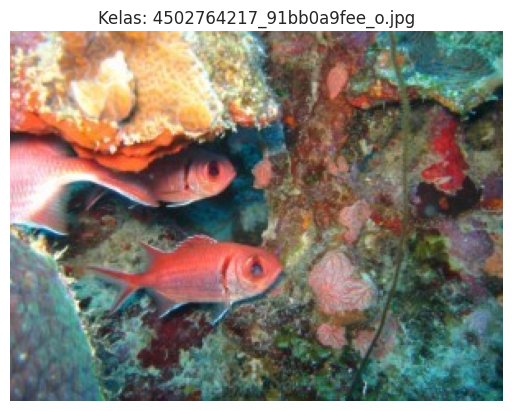

In [ ]:
#menulusuri isi folder
folder = os.listdir(download_path)
print("Isi folder:", folder)

#Menambil satu contoh gambar
data_dir = os.path.join(download_path, 'Fish')

img_name = os.listdir(os.path.join(data_dir))[0]
img_path = os.path.join(data_dir, img_name)

#Membaca dan menampilkan gambar
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #konversi warna untuk matplotlib

plt.imshow(img)
plt.title(f"Kelas: {img_name}")
plt.axis('off')
plt.show()

In [ ]:
#Melihat jumha file gambar
ttl_gambar = 0

for root, dirs, files in os.walk(download_path):
    #filter file gambar untuk akurasi
    images = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')) ]
    ttl_gambar += len(images)

print(f"Total seluruh gambar di dataset: {ttl_gambar}")

Total seluruh gambar di dataset: 13711


In [ ]:
#Melihat per kategori
categ = sorted(os.listdir(download_path))

print(f"{'Kategori':<20} | {'Jumlah Gambar'}")
print("-" * 35)

for cat in categ:
  cat_path = os.path.join(download_path, cat)
  if os.path.isdir(cat_path):
    n_img = len([f for f in os.listdir(cat_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    print(f"{cat:<20} | {n_img}")

Kategori             | Jumlah Gambar
-----------------------------------
Clams                | 497
Corals               | 500
Crabs                | 499
Dolphin              | 782
Eel                  | 497
Fish                 | 494
Jelly Fish           | 845
Lobster              | 499
Nudibranchs          | 500
Octopus              | 562
Otter                | 500
Penguin              | 482
Puffers              | 531
Sea Rays             | 517
Sea Urchins          | 579
Seahorse             | 478
Seal                 | 414
Sharks               | 590
Shrimp               | 488
Squid                | 483
Starfish             | 499
Turtle_Tortoise      | 1903
Whale                | 572


Dataset gambar pada submission ini sebanyak 13711 gambar, dari beberapa kategori dengan maksimal jumlah gambar pada kategori Turtle_Tortoise sebanyak 1903 gambar

In [ ]:
#Menyalin dataset ke google drive
#Hubungkan ke Google Drive
drive.mount('/content/drive')

#Tentukan nama folder tujuan di Google Drive
destination_path = '/content/drive/MyDrive/Colab Notebooks/Computer Vision/Dataset_Sea_Animals'

#Proses menyalin folder dari Kagglehub ke Google Drive
try:
    if 'download_path' in locals():
        print(f"Sedang menyalin data dari: {download_path}")
        shutil.copytree(download_path, destination_path, dirs_exist_ok=True)
        print(f"✅ Berhasil! Dataset sekarang ada di: {destination_path}")
    else:
        print("❌ Error: Variabel 'path' tidak ditemukan. Silakan jalankan ulang baris kagglehub.dataset_download tadi.")
except Exception as e:
    print(f"❌ Terjadi kesalahan saat menyalin: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sedang menyalin data dari: /root/.cache/kagglehub/datasets/vencerlanz09/sea-animals-image-dataste/versions/5
✅ Berhasil! Dataset sekarang ada di: /content/drive/MyDrive/Colab Notebooks/Computer Vision/Dataset_Sea_Animals


## **Data Preparation**

In [ ]:
#Mengubah nama file gambar sesuai nama folder

#defenisikan path penyimpanan gambar
root_path = '/content/drive/MyDrive/Colab Notebooks/Computer Vision/Dataset_Sea_Animals'

def rename_sea_animals_dataset(root_path):
    if not os.path.exists(root_path):
        print(f"Eror: Path {root_path} tidak ditemukan")
        return

    #Iterasi melalui folder hewan laut
    for folder_name in os.listdir(root_path):
        folder_path = os.path.join(root_path, folder_name)

        if os.path.isdir(folder_path):
            print(f"Sedang memproses: {folder_name}")

            #Ambil semua file dan urutkan agar rapi
            files = sorted(os.listdir(folder_path))

            counter = 1
            for filename in files:
                ext = os.path.splitext(filename)[1].lower()
                #Filter hanya file gambar
                if ext in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']:
                    #format nama: Namahewan_001.jpg
                    new_name = f"{folder_name}_{counter:03d}{ext}"

                    old_file = os.path.join(folder_path, filename)
                    new_file = os.path.join(folder_path, new_name)

                    try:
                        os.rename(old_file, new_file)
                        counter += 1
                    except Exception as e:
                        print(f"Gagal mengubah {filename}: {e}")

        print("\nProses selesai! Semua gambar hewan laut telah diganti namanya")

#proses rename
rename_sea_animals_dataset(root_path)

Sedang memproses: Corals

Proses selesai! Semua gambar hewan laut telah diganti namanya
Sedang memproses: Crabs

Proses selesai! Semua gambar hewan laut telah diganti namanya
Sedang memproses: Clams

Proses selesai! Semua gambar hewan laut telah diganti namanya
Sedang memproses: Lobster

Proses selesai! Semua gambar hewan laut telah diganti namanya
Sedang memproses: Jelly Fish

Proses selesai! Semua gambar hewan laut telah diganti namanya
Sedang memproses: Dolphin

Proses selesai! Semua gambar hewan laut telah diganti namanya
Sedang memproses: Eel

Proses selesai! Semua gambar hewan laut telah diganti namanya
Sedang memproses: Fish

Proses selesai! Semua gambar hewan laut telah diganti namanya
Sedang memproses: Nudibranchs

Proses selesai! Semua gambar hewan laut telah diganti namanya
Sedang memproses: Octopus

Proses selesai! Semua gambar hewan laut telah diganti namanya
Sedang memproses: Otter

Proses selesai! Semua gambar hewan laut telah diganti namanya
Sedang memproses: Puffers

P

Data preparation merupakan langkah untuk menyiapkan data dengan menyimpan semua gambar kedalam Google Drive sehingga tidak terus meminta akses ke kagglegub. Kemudian untuk memudahkan mengetahui gambar, format file gambar diubah sesuai dengan nama folder penyimpanan diikuti dengan nomor urut.

## **Dataset Checking**

Bagian ini mempersiapkan dataset yang akan digunakan untuk melatih model.

In [5]:
#Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
animal_img ={}

#tentukan path sumber
path = "/content/drive/MyDrive/Computer_Vision"

path_sub = os.path.join(path, 'Dataset_Sea_Animals')
for i in os.listdir(path_sub):
    full_sub_path = os.path.join(path_sub, i)
    # Pastikan hanya memproses jika itu adalah folder
    if os.path.isdir(full_sub_path):
        animal_img[i] = os.listdir(full_sub_path)

#Menampilkan secara acak 5 gambar dibawah setiap dari 23 kelas data
fig, axs = plt.subplots(len(animal_img.keys()), 2, figsize=(15, 60))

for i, class_name in enumerate(animal_img.keys()):
    img = np.random.choice(animal_img[class_name], 2, replace=False)

    for j, img_name in enumerate(img):
        img_path = os.path.join(path_sub, class_name, img_name)
        images = Image.open(img_path).convert("RGB") #Konversi menjadi berwarna
        axs[i, j].imshow(images)
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])

fig.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#melihat dimensi dari salah satu data set gambar
path_img = "/content/drive/MyDrive/Computer_Vision/Dataset_Sea_Animals/Seal/*.jpg"

shapes=[]

for file in glob.glob(path_img, recursive=True):
    imgforshape = cv2.imread(file)
    if imgforshape is not None:
        shapes.append(imgforshape.shape)

#Melihat 5 shape pertama
print(f"Daftar shape: {shapes[:5]}")

#Mengecek apakah semua gambar punya ukuran yang sama
unique_shapes = set(shapes)
print(f"Total shape unik: {len(unique_shapes)}")
print(f"Detail shape unik: {unique_shapes}")

Daftar shape: [(225, 300, 3), (193, 300, 3), (300, 279, 3), (225, 300, 3), (201, 300, 3)]
Total shape unik: 73
Detail shape unik: {(190, 300, 3), (275, 300, 3), (300, 146, 3), (259, 300, 3), (225, 300, 3), (300, 245, 3), (203, 300, 3), (300, 300, 3), (174, 300, 3), (247, 300, 3), (209, 300, 3), (187, 300, 3), (214, 300, 3), (300, 265, 3), (165, 300, 3), (300, 201, 3), (300, 223, 3), (227, 300, 3), (300, 225, 3), (233, 300, 3), (221, 300, 3), (199, 300, 3), (177, 300, 3), (234, 300, 3), (224, 300, 3), (195, 300, 3), (207, 300, 3), (185, 300, 3), (300, 240, 3), (258, 300, 3), (230, 300, 3), (208, 300, 3), (183, 300, 3), (300, 200, 3), (196, 300, 3), (219, 300, 3), (242, 300, 3), (220, 300, 3), (232, 300, 3), (198, 300, 3), (222, 300, 3), (169, 300, 3), (210, 300, 3), (226, 300, 3), (192, 300, 3), (204, 300, 3), (300, 169, 3), (300, 279, 3), (276, 300, 3), (193, 300, 3), (217, 300, 3), (300, 259, 3), (176, 300, 3), (266, 300, 3), (205, 300, 3), (218, 300, 3), (216, 300, 3), (228, 300, 3),

Dataset gambar pada proyek ini tidak seragam, misalnya terdiri dari dimensi untuk gambar yang ada pada folder Seal saja [(196, 300, 3), (200, 300, 3), (200, 300, 3), (169, 300, 3), (225, 300, 3)]

## **Plot Distribusi**

Plot distribusi memberikan gambaran persebaran jumlah dataset gambar setiap kelasnya

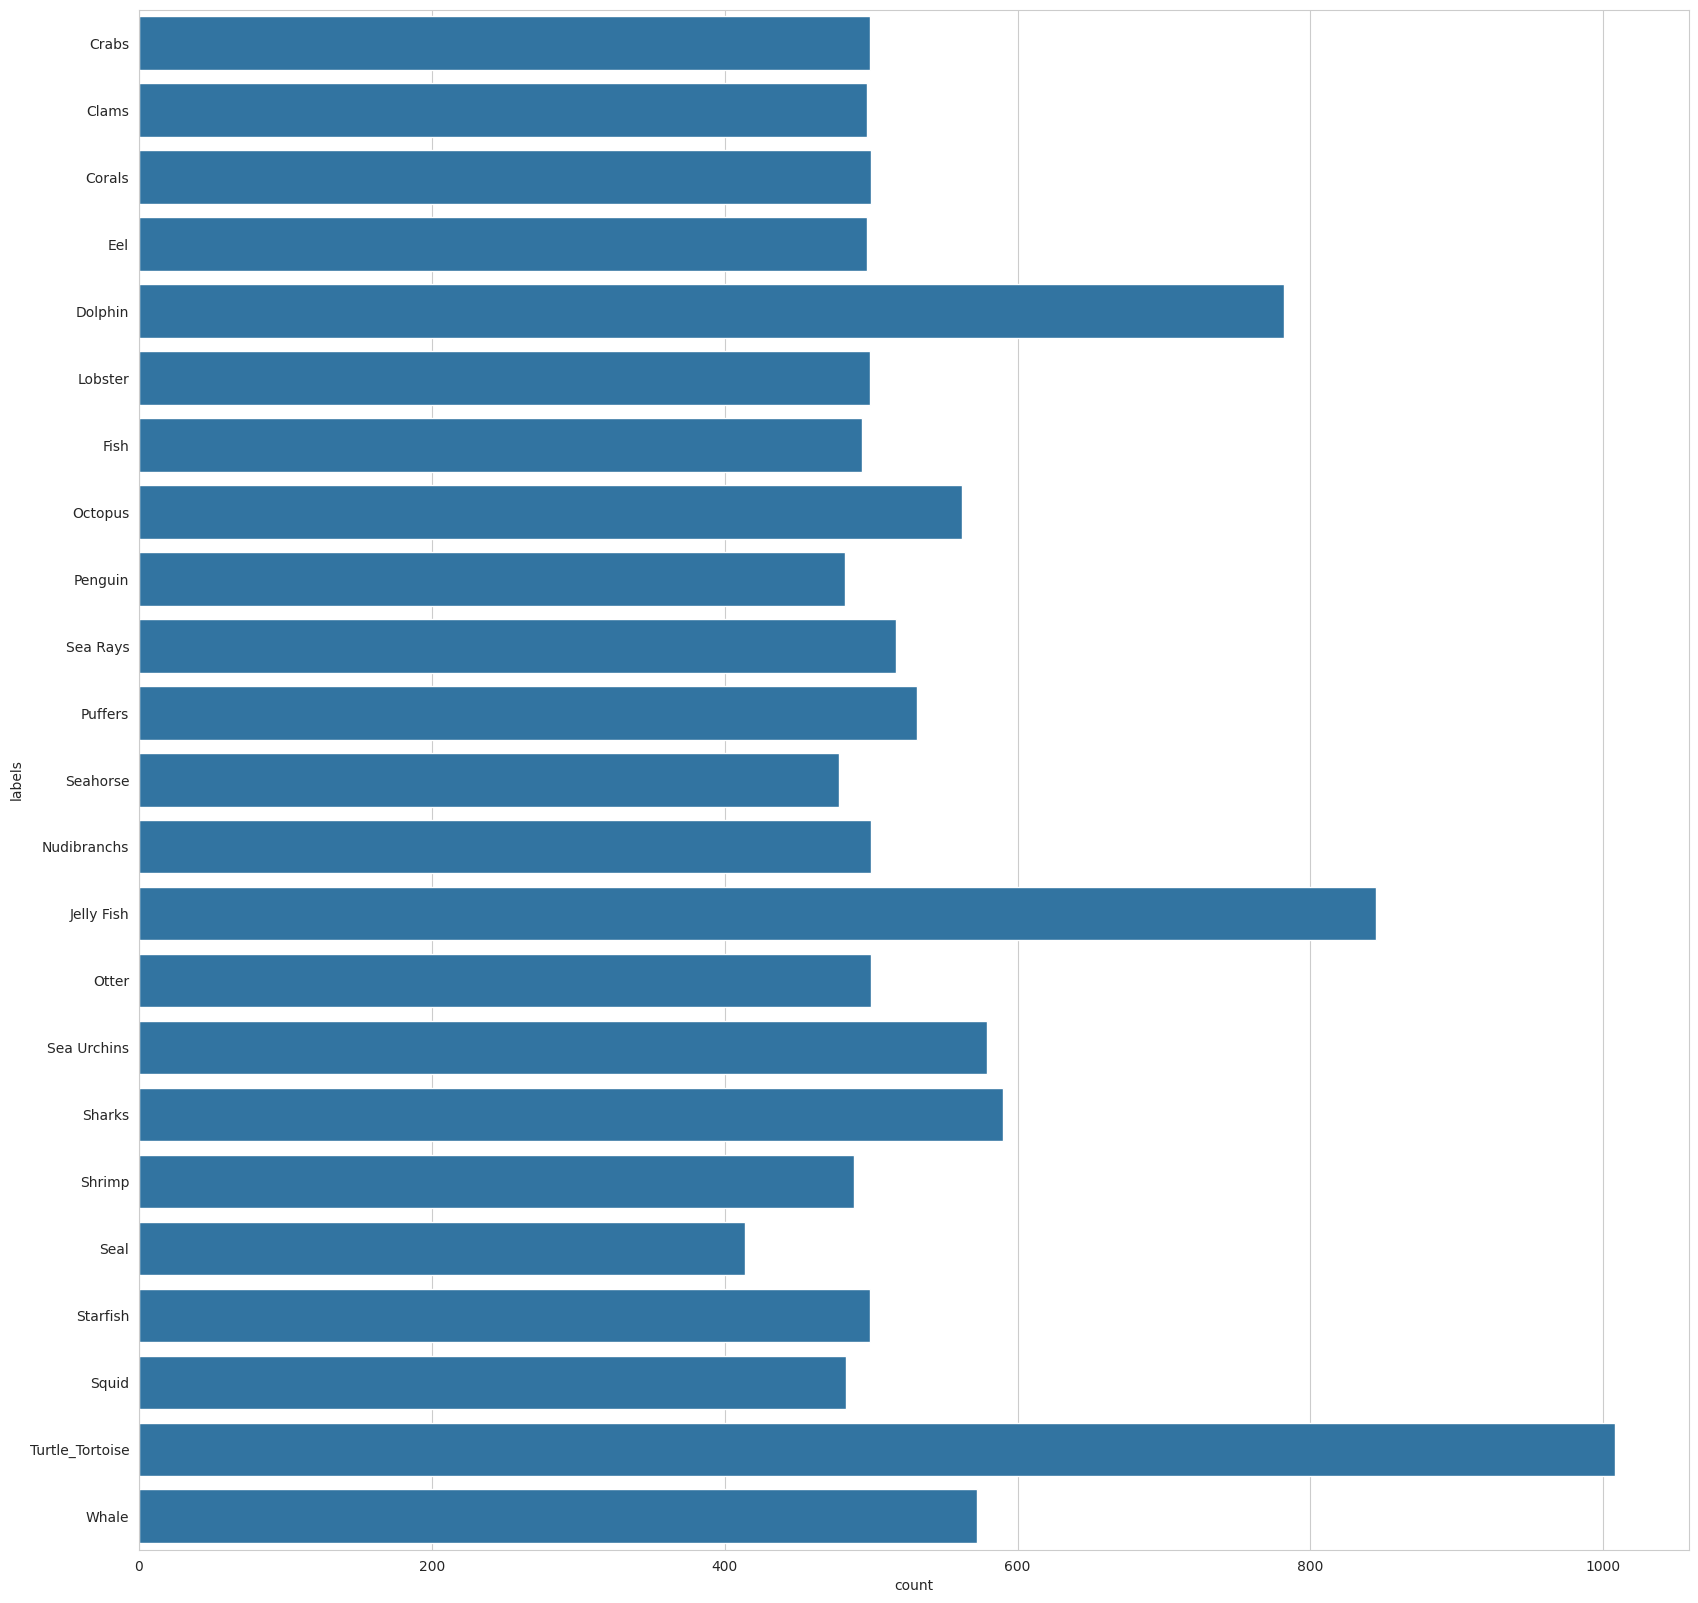

In [ ]:
#Defenisi path sumber
animal_path = "/content/drive/MyDrive/Computer_Vision/Dataset_Sea_Animals"

#buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels =[]
full_path=[]

#dapatkan nama file gambar, path file, dan label satu per satu dengan looping dan simpan sebagai dataframe
for path, subdirs, files in os.walk(animal_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

dist_data= pd.DataFrame({"path": full_path, "file_name": file_name, "labels": labels})

#Plot distribusi gambar di setiap kelas
Label = dist_data['labels']
plt.figure(figsize=(20, 20))
sns.set_style("whitegrid")
plot_data = sns.countplot(Label)

Pada plot diatas terlihat gambar spesies kura-kura paling banyak diantara data gambar lainnya lebih dari 1000 gambar

## **Data Augmentation**

Untuk membantu mencegah overfitting, yakni ketika model terlalu terbiasa dengan data pelatihan dan tidak dapat menggeneralisasi data baru dengan baik, Proses augmentasi gambar adalah teknik yang digunakan dalam membuat variasi baru dari setiap gambar pada dataset sehingga model memiliki lebih banyak variasi untuk dipelajari.

In [ ]:
#Membuat fungsi untuk melakukan rotasi berlawanan arah jarum jam
def anticlockwise_rotation(img):
    #img = cv2.cvtColor(img, 0)
    img_res = cv2.resize(img, (224, 224))
    sudut = random.randint(0, 180)
    hasil = sk_rotate(img_res, sudut)
    return img_as_ubyte(hasil)

In [ ]:
#Membuat fungsi untuk melakukan rotasi searah jarum jam
def clockwise_rotation(img):
    #img = cv2.cvtColor(img, 0)
    img_res = cv2.resize(img, (224, 224))
    sudut = random.randint(0, 180)
    hasil = sk_rotate(img_res, -sudut)
    return img_as_ubyte(hasil)

In [ ]:
#Membuat fungsi untuk membalik gambar secara vertikal dari atas ke bawah
def flip_up_down(img):
    #img = cv2.cvtColor(img, 0)
    img_res = cv2.resize(img, (224, 224))
    flip_img = np.flipud(img_res)
    return flip_img.astype(np.uint8)

In [ ]:
#Membuat fungsi untuk memberikan efek peningkatan kecerahan pada gambar
def add_brightness(img):
    #img = cv2.cvtColor(img, 0)
    img_res = cv2.resize(img, (224, 224))
    hasil = adjust_gamma(img_res, gamma=0.5, gain=1)
    return img_as_ubyte(hasil)

In [ ]:
#Membuat fungsi untuk memberikan efek blur pada gambar
def blur_image(img):
    #img = cv2.cvtColor(img, 0)
    img_res = cv2.resize(img, (224, 224))
    blurred = cv2.GaussianBlur(img, (9,9), 0)
    return blurred.astype(np.uint8)

In [ ]:
#Membuat fungsi untuk memberikan efek pergeseran acak pada gambar
def sheared(img):
    #img = cv2.cvtColor(img, 0)
    img_res = cv2.resize(img, (224, 224))
    transf =AffineTransform(shear=0.2)
    shear_image = warp(img_res, transf, mode="wrap")
    return img_as_ubyte(shear_image)

In [ ]:
def warp_shift(img):
    #img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224, 224))
    transform = AffineTransform(translation=(0, 40))
    warp_image = warp(img, transform, mode="wrap")
    return img_as_ubyte(warp_image)

In [ ]:
# Membuat variabel transformasi yang akan menyimpan semua proses pra-pemrosesan yang telah dilakukan sebelumnya
transformations = { 'rotate anticlockwise': anticlockwise_rotation,
                    'rotate clockwise': clockwise_rotation,
                    'warp shift': warp_shift,
                    'blurring image': blur_image,
                    'add brightness' : add_brightness,
                    'flip up down': flip_up_down,
                    'shear image': sheared
                  }

In [ ]:
def ensure_uint8(img):
    """Memastikan gambar dalam format uint8 (0-255) untuk OpenCV"""
    # Jika gambar dalam format float (0.0 - 1.0)
    if img.dtype == np.float64 or img.dtype == np.float32:
        return img_as_ubyte(img)
    # Jika sudah dalam format integer tapi bukan uint8
    return img.astype(np.uint8)

In [ ]:
from os.path import exists
from IPython.utils.path import target_outdated
#inisialisasi path sumber animal_path pada cell sebelumnya

#inisialisasi path augment
aug_path = "/content/drive/MyDrive/Computer_Vision/Augmented_Sea_Animals"

img_aug = [] #penyimpanan gambar yang telah melalui pemrosesan

#target total gamabr per kelas (Asli + augmentasi)
target_total = 1000

categ = [f for f in os.listdir(animal_path) if os.path.isdir(os.path.join(animal_path, f))]

for kategori in categ:
    img_path = os.path.join(animal_path, kategori)
    augment = os.path.join(aug_path, kategori)

    if not os.path.exists(augment):
        os.makedirs(augment, exist_ok=True)

    #ambil daftar dari gambar asli
    imgs = [os.path.join(img_path, im) for im in os.listdir(img_path)
            if im.lower().endswith(('.png', '.jpg', '.jpeg'))]

    jumlah_asli = len(imgs)

    #Hitung sisa yang perlu dibuat (target-asli)
    #jika data asli sudah >= 2000, maka tidak diaugmentasi
    need_to_generate = target_total - jumlah_asli

    if need_to_generate <= 0:
        print(f"Kategori {kategori} sudah cukup ({jumlah_asli} gambar)")
        continue

    print(f"Kategori {kategori}: Asli={jumlah_asli}, membuat= {need_to_generate}")

    i=1
    while i <= need_to_generate:
        image = random.choice(imgs)
        try:
            ori_img = cv2.imread(image)
            if ori_img is None:
                continue

            #Konversi BGR ke RGB karena fungsi transformasi
            ori_img = cv2.cvtColor(ori_img, cv2.COLOR_BGR2RGB)
            transform_img = ori_img.copy()

            #pilih jumlah transformasi yang diterapkan
            transform_count = random.randint(1, len(transformations))

            #Terapkan transformasi secara acak
            for _ in range(transform_count):
                key = random.choice(list(transformations))
                transform_img = transformations[key](transform_img)

            #format nama: aug_kategori_001.jpg
            new_img_name = f"aug_{kategori}_{i:03d}.jpg"
            save_path = os.path.join(augment, new_img_name)

            #Memastikan format uint8 untuk openCV
            transform_img = ensure_uint8(transform_img)

            #Konversi RGB ke BGR untuk cv2.imwrite agar warna tidak tertukar
            final_img = cv2.cvtColor(transform_img, cv2.COLOR_RGB2BGR)

            cv2.imwrite(save_path, final_img)
            i +=1

        except Exception as e:
            print(f"Gagal memproses {image}: {e}")
print("Proses penyeimbang dataset selesai")

Kategori Crabs: Asli=499, membuat= 501
Kategori Clams: Asli=497, membuat= 503
Kategori Corals: Asli=500, membuat= 500
Kategori Eel: Asli=497, membuat= 503
Kategori Dolphin: Asli=782, membuat= 218
Kategori Lobster: Asli=499, membuat= 501
Kategori Fish: Asli=494, membuat= 506
Kategori Octopus: Asli=562, membuat= 438
Kategori Penguin: Asli=482, membuat= 518
Kategori Sea Rays: Asli=517, membuat= 483
Kategori Puffers: Asli=531, membuat= 469
Kategori Seahorse: Asli=478, membuat= 522
Kategori Nudibranchs: Asli=500, membuat= 500
Kategori Jelly Fish: Asli=845, membuat= 155
Kategori Otter: Asli=500, membuat= 500
Kategori Sea Urchins: Asli=579, membuat= 421
Kategori Sharks: Asli=590, membuat= 410
Kategori Shrimp: Asli=488, membuat= 512
Kategori Seal: Asli=414, membuat= 586
Kategori Starfish: Asli=499, membuat= 501
Kategori Squid: Asli=483, membuat= 517
Kategori Turtle_Tortoise sudah cukup (1008 gambar)
Kategori Whale: Asli=572, membuat= 428
Proses penyeimbang dataset selesai


(array([  0., 100., 200., 300., 400., 500., 600., 700.]),
 [Text(0.0, 0, '0'),
  Text(100.0, 0, '100'),
  Text(200.0, 0, '200'),
  Text(300.0, 0, '300'),
  Text(400.0, 0, '400'),
  Text(500.0, 0, '500'),
  Text(600.0, 0, '600'),
  Text(700.0, 0, '700')])

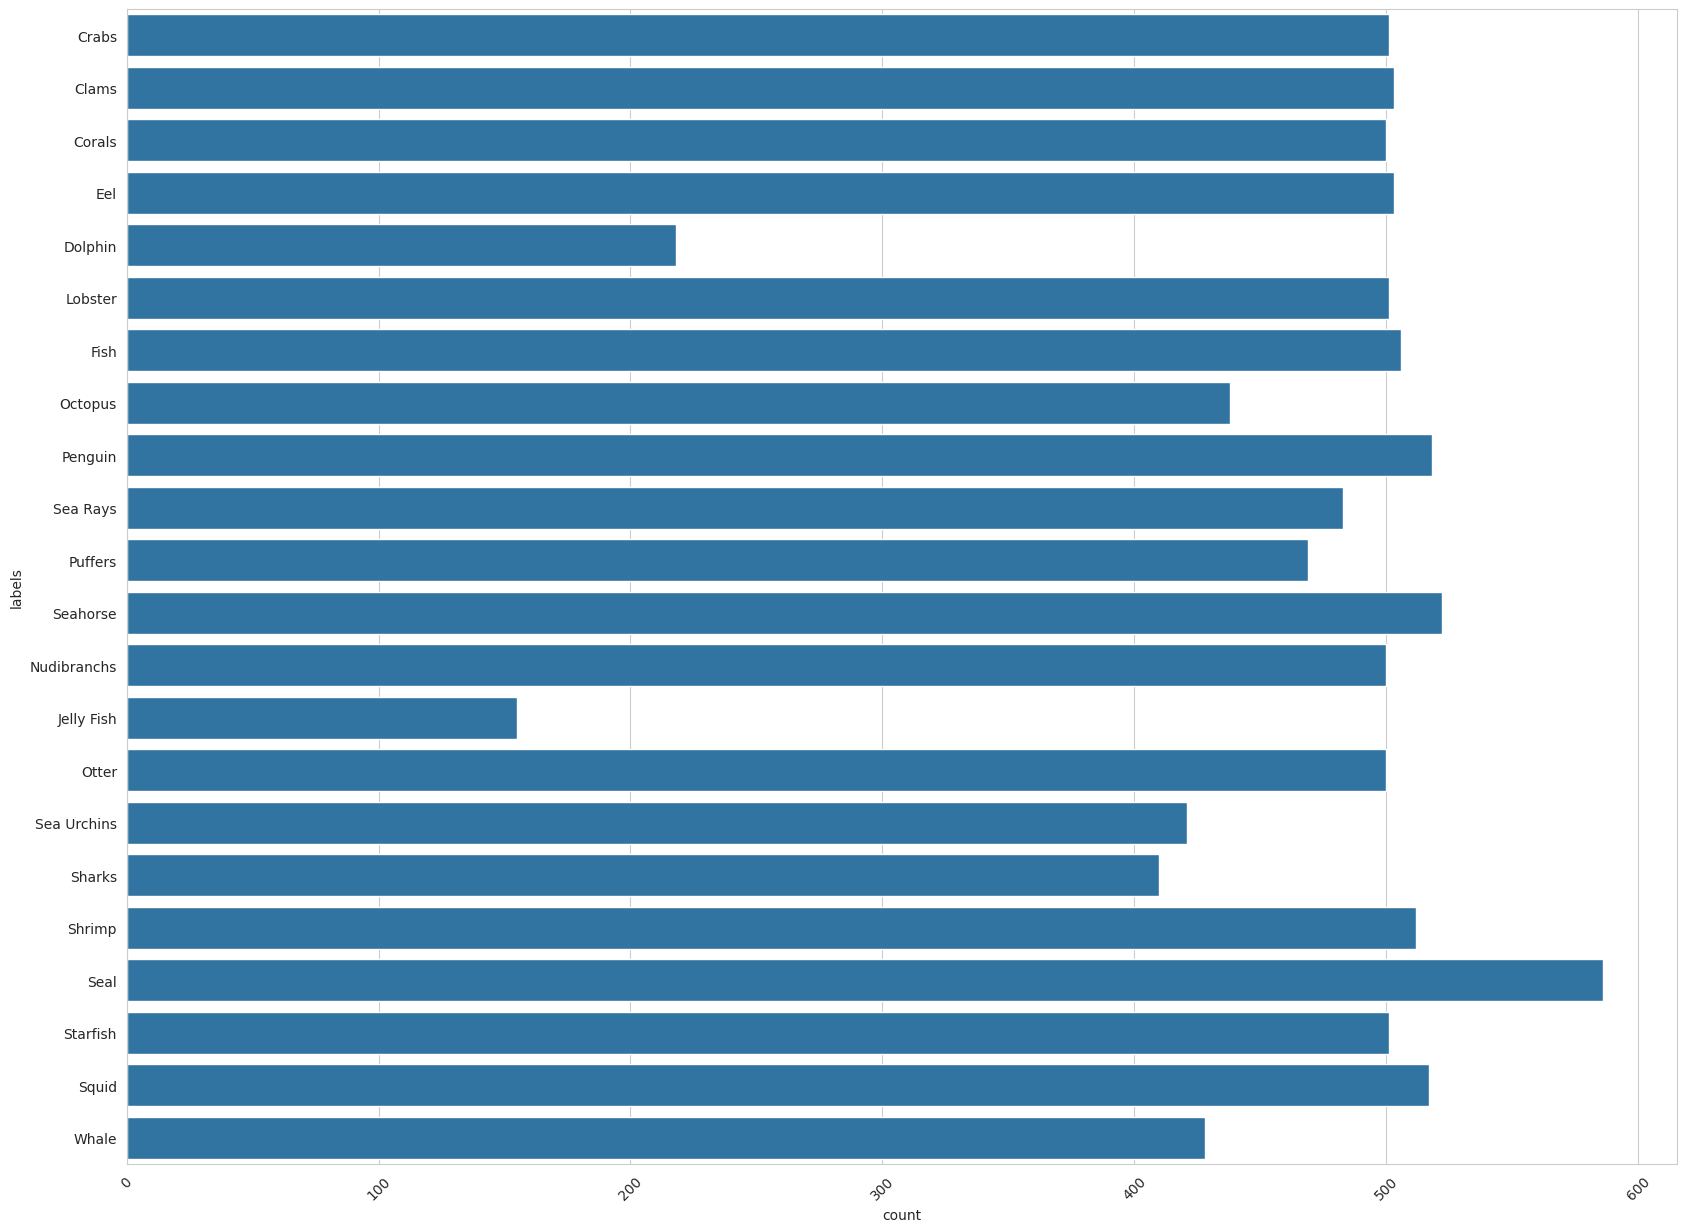

In [ ]:
#Melihat plot seluruh gambar setelah di augmentasi

#inisialisasi path sumber
#path_asli = "/content/drive/MyDrive/Colab Notebooks/Computer Vision/Dataset_Sea_Animals"
path_aug = "/content/drive/MyDrive/Computer_Vision/Augmented_Sea_Animals"

#Buat daftar yang menyimpan data
file_name = []
labels =[]
full_path=[]

#dapatkan nama file gambar, path file, dan label satu per satu dengan looping dan simpan sebagai dataframe
#for pathnya, subdirs, files in os.walk(path_aug):
#    for name in files:
#        full_path.append(os.path.join(pathnya, name))
#        labels.append(pathnya.split('/')[-1])
#        file_name.append(name)

#Loop kedua untuk Data Augmentasi (Menambah ke list yang sama)
for pathnya, subdirs, files in os.walk(path_aug):
    for name in files:
        if name.lower().endswith(('.png', '.jpg', '.jpeg')):
            full_path.append(os.path.join(pathnya, name))
            labels.append(pathnya.split('/')[-1])
            file_name.append(name)

dist_data= pd.DataFrame({"path": full_path, "file_name": file_name, "labels": labels})

#Plot distribusi gambar di setiap kelas
Label = dist_data['labels']
plt.figure(figsize=(20, 15))
sns.set_style("whitegrid")
plot_data = sns.countplot(Label)

plt.xticks(rotation=45)

Augmentasi dilakukan untuk mencegah data imbalance. Setiap kelas di lakukan augmentasi agar membuat data gambar perjelas sebanyak 1000 gambar

## **Data Splitting**

Pada tahap ini data akan dibagi untuk keperluan pembejaran mengenali gambar. Data akan dibagi menjadi data train, validation, dan test. Ketiganya akan dipisahkan sesuai porsinya.

In [ ]:
#panggil variabel 'path' yang sudah didefenisikan pada cell sbelumnya
path_asli = "/content/drive/MyDrive/Computer_Vision/Dataset_Sea_Animals"

#membuat listuntuk menanpung data
file_name =[]
labels = []
full_path =[]

for pathlg, subdirs, files in os.walk(path_asli):
    for name in files:
      if name.lower().endswith(('.png', '.jpg', '.jpeg')):
          full_path.append(os.path.join(pathlg, name))
          labels.append(pathlg.split('/')[-1])
          file_name.append(name)

#Loop kedua untuk Data Augmentasi (Menambah ke list yang sama)
#for pathnya, subdirs, files in os.walk(path_aug):
#    for name in files:
#        if name.lower().endswith(('.png', '.jpg', '.jpeg')):
#            full_path.append(os.path.join(pathnya, name))
#            labels.append(pathnya.split('/')[-1])
#            file_name.append(name)

#Memasukkan variabel yang sudah dikumpulkan pada looping diatas menjadi sebuah dataframe
df_data = pd.DataFrame({"path": full_path, "file_name": file_name, "labels": labels})

#Melihat jumlah data gambar pada masing-masing label
df_data.groupby(['labels']).size()

,0
labels,
Clams,497
Corals,500
Crabs,499
Dolphin,782
Eel,497
Fish,494
Jelly Fish,845
Lobster,499
Nudibranchs,500


In [ ]:
#Membuat kamus untuk data augmentasi
#panggil variabel 'path' yang sudah didefenisikan pada cell sbelumnya
path_aug = "/content/drive/MyDrive/Computer_Vision/Augmented_Sea_Animals"

#membuat listuntuk menanpung data
file_name =[]
labels = []
full_path =[]

#for pathlg, subdirs, files in os.walk(path_asli):
#    for name in files:
#      if name.lower().endswith(('.png', '.jpg', '.jpeg')):
#          full_path.append(os.path.join(pathlg, name))
#          labels.append(pathlg.split('/')[-1])
#          file_name.append(name)

#Loop kedua untuk Data Augmentasi (Menambah ke list yang sama)
for pathnya, subdirs, files in os.walk(path_aug):
    for name in files:
        if name.lower().endswith(('.png', '.jpg', '.jpeg')):
            full_path.append(os.path.join(pathnya, name))
            labels.append(pathnya.split('/')[-1])
            file_name.append(name)

#Memasukkan variabel yang sudah dikumpulkan pada looping diatas menjadi sebuah dataframe
df_data_aug = pd.DataFrame({"path": full_path, "file_name": file_name, "labels": labels})

#Melihat jumlah data gambar pada masing-masing label
df_data_aug.groupby(['labels']).size()

,0
labels,
Clams,503
Corals,500
Crabs,501
Dolphin,218
Eel,503
Fish,506
Jelly Fish,155
Lobster,501
Nudibranchs,500


Setelah mendapatkan variabel yang dibutuhkan untuk pemisahan data, selanjutnya membagi variabel menjadi variabel X dan y

In [ ]:
X = df_data['path']
y = df_data['labels']

In [ ]:
#Split dataset awal menjadi data tarin 80%, vaidation + test 20%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state =300)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.5, stratify = y_temp, random_state = 300
)

In [ ]:
#Menyatukan kedalam masing-masing dataframe
df_tr = pd.DataFrame({'path': X_train, 'labels': y_train, 'set': 'train'})
df_val = pd.DataFrame({'path' : X_val, 'labels': y_val, 'set': 'validation'})
df_te = pd.DataFrame({'path': X_test, 'labels': y_test, 'set': 'test'})

In [ ]:
#menaytukan data augmentasi dan data train# Tambahkan penanda bahwa data augmentasi termasuk train
df_data_aug['set'] = 'train'

# Gabungkan train asli + augmentasi
df_tr_final = pd.concat([df_tr, df_data_aug], ignore_index=True)

# Cek hasil gabungan
print(df_tr_final.groupby(['set', 'labels']).size())

set    labels         
train  Clams              896
       Corals             891
       Crabs              908
       Dolphin            854
       Eel                908
       Fish               929
       Jelly Fish         828
       Lobster            904
       Nudibranchs        892
       Octopus            905
       Otter              902
       Penguin            907
       Puffers            902
       Sea Rays           892
       Sea Urchins        875
       Seahorse           897
       Seal               918
       Sharks             879
       Shrimp             893
       Squid              893
       Starfish           891
       Turtle_Tortoise    799
       Whale              881
dtype: int64


In [ ]:
#Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr_final, df_val, df_te], ignore_index=True)

print('===========================================\n')
print(df_all.groupby(['set', 'labels']).size())
print('===========================================\n')

#Cek sampel data
print(df_all.sample(5))

#Memanggil dataset asli yang berisi keseluruhan gambar yang sesuai dengan labelnya
#inisialisasi 'path' pada cell sebelumnya
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "/content/drive/MyDrive/Computer_Vision/"


set         labels         
test        Clams               52
            Corals              54
            Crabs               46
            Dolphin             73
            Eel                 46
                              ... 
validation  Shrimp              54
            Squid               54
            Starfish            54
            Turtle_Tortoise    104
            Whale               60
Length: 69, dtype: int64

                                                    path       labels    set  \
13120  /content/drive/MyDrive/Computer_Vision/Augment...         Fish  train   
3677   /content/drive/MyDrive/Computer_Vision/Dataset...      Puffers  train   
44     /content/drive/MyDrive/Computer_Vision/Dataset...       Shrimp  train   
15445  /content/drive/MyDrive/Computer_Vision/Augment...     Seahorse  train   
7404   /content/drive/MyDrive/Computer_Vision/Dataset...  Nudibranchs  train   

                  file_name  
13120      aug_Fish_143.jpg  
3677               

In [ ]:
bad_images = []

for path in df_all['path']:
    try:
        img = Image.open(path)
        img.verify()
    except:
        bad_images.append(path)

print("Jumlah gambar rusak:", len(bad_images))
print(bad_images[:5])

Jumlah gambar rusak: 0
[]


Selanjutnya, proses mencetak distribusi data untuk memastikan bahwa pembagian data telah dilakukan dengan benar, kemudian mengatur variabel path untuk dataset asli dan dataset yang sudah dibagi, yang akan digunakan pada tahap pemrosesan berikutnya.

In [ ]:
for index, row in tq(df_all.iterrows()):
    #Deteksi filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
        file_path = os.path.join(path, row['labels'], row['image'].split('.')[0])

    #Buat diretori tujuan
    if os.path.exists(os.path.join(dataset_path, row['set'], row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path, row['set'], row['labels']))

    #Tentukan tujuan file
    dest_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path, row['set'], row['labels'], dest_file_name)

    #Salin file dari sumber tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path, file_dest)

0it [00:00, ?it/s]

Dataset sudah dibagi menjadi data train dan data test, masing-masing tersimpan di Google Drive

In [ ]:
#Proses zip file
#Bersihkan folder sementara di Runtime
!rm -rf /content/data_lokal

In [ ]:
#Membuat zip dari folder train dan test yang ada di Drive
!zip -r "/content/drive/MyDrive/Computer_Vision/dataset_gambar_laut.zip" \
"/content/drive/MyDrive/Computer_Vision/train"\
"/content/drive/MyDrive/Computer_Vision/validation"\
"/content/drive/MyDrive/Computer_Vision/test"

Output streaming akan dipotong hingga 5000 baris terakhir.
  adding: content/drive/MyDrive/Computer_Vision/train/Seal/Seal_215.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Seal/Seal_343.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Seal/Seal_212.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Seal/Seal_150.jpg (deflated 2%)
  adding: content/drive/MyDrive/Computer_Vision/train/Seal/Seal_287.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Seal/Seal_100.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Seal/Seal_043.jpg (deflated 2%)
  adding: content/drive/MyDrive/Computer_Vision/train/Seal/Seal_113.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Seal/Seal_332.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Seal/Seal_027.jpg (deflated 2%)
  adding: content/drive/MyDrive/Computer_Vision/train/Seal/Seal_173.jpg (deflated

In [20]:
# Memindahkan dan mengekstrak ke folder /content/data_lokal
!unzip -q "/content/drive/MyDrive/Computer_Vision/dataset_gambar_laut.zip" -d /content/data_lokal

replace /content/data_lokal/content/drive/MyDrive/Computer_Vision/train/Sea Rays/Sea Rays_154.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [21]:
path_zip = '/content/data_lokal'
print(os.listdir(path_zip))

['content']


## **Image Data Generator**

Image data generator pada sesi ini digunakan untuk membagi dataset menjadi dataset pelatihan dan validasi, serta normalisasi gambar dengan menskalakan nilai piksel

In [22]:
#Defenisikan direktori tarining dan test
base_zip = '/content/data_lokal/content/drive/MyDrive/Computer_Vision/'
train_zip = os.path.join(base_zip, 'train')
val_zip = os.path.join(base_zip, 'validation')
test_zip = os.path.join(base_zip, 'test')
#TRAIN_DIR = "/content/drive/MyDrive/Colab Notebooks/Computer Vision/train/"
#TEST_DIR = "/content/drive/MyDrive/Colab Notebooks/Computer Vision/test/"

train_sea_urchins = os.path.join(train_zip + '/Sea Urchins')
train_whale = os.path.join(train_zip + '/Whale')
train_fish = os.path.join(train_zip + '/Fish')
train_clams = os.path.join(train_zip + '/Clams')
train_seal = os.path.join(train_zip + '/Seal')
train_sea_rays = os.path.join(train_zip + '/Sea Rays')
train_octopus = os.path.join(train_zip + '/Octopus')
train_nudibranch = os.path.join(train_zip + '/Nudibranchs')
train_shrimp = os.path.join(train_zip + '/Shrimp')
train_eel = os.path.join(train_zip + '/Eel')
train_lobster = os.path.join(train_zip + '/Lobster')
train_seahorse = os.path.join(train_zip + '/Seahorse')
train_coral = os.path.join(train_zip + '/Corals')
train_squid = os.path.join(train_zip + '/Squid')
train_dolphin = os.path.join(train_zip + '/Dolphin')
train_crabs = os.path.join(train_zip+ '/Crabs')
train_puffers = os.path.join(train_zip + '/Puffers')
train_penguin = os.path.join(train_zip + '/Penguin')
train_turtle = os.path.join(train_zip + '/Turtle_Tortoise')
train_sharks = os.path.join(train_zip + '/Sharks')
train_starfish = os.path.join(train_zip + '/Starfish')
train_otter= os.path.join(train_zip + '/Otter')
train_jelly_fish = os.path.join(train_zip + '/Jelly Fish')

test_sea_urchins = os.path.join(test_zip + '/Sea Urchins')
test_whale = os.path.join(test_zip+ '/Whale')
test_fish = os.path.join(test_zip + '/Fish')
test_clams = os.path.join(test_zip + '/Clams')
test_seal = os.path.join(test_zip + '/Seal')
test_sea_rays = os.path.join(test_zip + '/Sea Rays')
test_octopus = os.path.join(test_zip + '/Octopus')
test_nudibranch = os.path.join(test_zip + '/Nudibranchs')
test_shrimp = os.path.join(test_zip + '/Shrimp')
test_eel = os.path.join(test_zip + '/Eel')
test_lobster = os.path.join(test_zip + '/Lobster')
test_seahorse = os.path.join(test_zip + '/Seahorse')
test_coral = os.path.join(test_zip+ '/Corals')
test_squid = os.path.join(test_zip + '/Squid')
test_dolphin = os.path.join(test_zip + '/Dolphin')
test_crabs = os.path.join(test_zip + '/Crabs')
test_puffers = os.path.join(test_zip + '/Puffers')
test_penguin = os.path.join(test_zip + '/Penguin')
test_turtle = os.path.join(test_zip + '/Turtle_Tortoise')
test_sharks = os.path.join(test_zip + '/Sharks')
test_starfish = os.path.join(test_zip + '/Starfish')
test_otter= os.path.join(test_zip + '/Otter')
test_jelly_fish = os.path.join(test_zip + '/Jelly Fish')

print("Total number of Sea Urchins in training set: ", len(os.listdir(train_sea_urchins)))
print("Total number of Whale in training set: ", len(os.listdir(train_whale)))
print("Total number of Fish in training set: ", len(os.listdir(train_fish)))
print("Total number of Clams in training set: ", len(os.listdir(train_clams)))
print("Total number of Seal in training set: ", len(os.listdir(train_seal)))
print("Total number of Sea Rays in training set: ", len(os.listdir(train_sea_rays)))
print("Total number of Octopus in training set: ", len(os.listdir(train_octopus)))
print("Total number of Nudibranchs in training set: ", len(os.listdir(train_nudibranch)))
print("Total number of Shrimp in training set: ", len(os.listdir(train_shrimp)))
print("Total number of Eel in training set: ", len(os.listdir(train_eel)))
print("Total number of Lobster in training set: ", len(os.listdir(train_lobster)))
print("Total number of Seahorse in training set: ", len(os.listdir(train_seahorse)))
print("Total number of Coral in training set: ", len(os.listdir(train_coral)))
print("Total number of Squid in training set: ", len(os.listdir(train_squid)))
print("Total number of Dolphin in training set: ", len(os.listdir(train_dolphin)))
print("Total number of Crabs in training set: ", len(os.listdir(train_crabs)))
print("Total number of Puffers in training set: ", len(os.listdir(train_puffers)))
print("Total number of Penguin in training set: ", len(os.listdir(train_penguin)))
print("Total number of Turtle and Tortoise in training set: ", len(os.listdir(train_turtle)))
print("Total number of Shark in training set: ", len(os.listdir(train_sharks)))
print("Total number of Starfish in training set: ", len(os.listdir(train_starfish)))
print("Total number of Otter in training set: ", len(os.listdir(train_otter)))
print("Total number of Jelly Fish in training set: ", len(os.listdir(train_jelly_fish)))

print("Total number of Sea Urchins in test set: ", len(os.listdir(test_sea_urchins)))
print("Total number of Whale in test set: ", len(os.listdir(test_whale)))
print("Total number of Fish in test set: ", len(os.listdir(test_fish)))
print("Total number of Clams in test set: ", len(os.listdir(test_clams)))
print("Total number of Seal in test set: ", len(os.listdir(test_seal)))
print("Total number of Sea Rays in test set: ", len(os.listdir(test_sea_rays)))
print("Total number of Octopus in test set: ", len(os.listdir(test_octopus)))
print("Total number of Nudibranchs in test set: ", len(os.listdir(test_nudibranch)))
print("Total number of Shrimp in test set: ", len(os.listdir(test_shrimp)))
print("Total number of Eel in test set: ", len(os.listdir(test_eel)))
print("Total number of Lobster in test set: ", len(os.listdir(test_lobster)))
print("Total number of Seahorse in test set: ", len(os.listdir(test_seahorse)))
print("Total number of Coral in test set: ", len(os.listdir(test_coral)))
print("Total number of Squid in test set: ", len(os.listdir(test_squid)))
print("Total number of Dolphin in test set: ", len(os.listdir(test_dolphin)))
print("Total number of Crabs in test set: ", len(os.listdir(test_crabs)))
print("Total number of Puffers in test set: ", len(os.listdir(test_puffers)))
print("Total number of Penguin in test set: ", len(os.listdir(test_penguin)))
print("Total number of Turtle and Tortoise in test set: ", len(os.listdir(test_turtle)))
print("Total number of Shark in test set: ", len(os.listdir(test_sharks)))
print("Total number of Starfish in test set: ", len(os.listdir(test_starfish)))
print("Total number of Otter in test set: ", len(os.listdir(test_otter)))
print("Total number of Jelly Fish in test set: ", len(os.listdir(test_jelly_fish)))

Total number of Sea Urchins in training set:  875
Total number of Whale in training set:  881
Total number of Fish in training set:  929
Total number of Clams in training set:  896
Total number of Seal in training set:  918
Total number of Sea Rays in training set:  892
Total number of Octopus in training set:  905
Total number of Nudibranchs in training set:  892
Total number of Shrimp in training set:  893
Total number of Eel in training set:  908
Total number of Lobster in training set:  904
Total number of Seahorse in training set:  897
Total number of Coral in training set:  891
Total number of Squid in training set:  893
Total number of Dolphin in training set:  854
Total number of Crabs in training set:  908
Total number of Puffers in training set:  902
Total number of Penguin in training set:  907
Total number of Turtle and Tortoise in training set:  799
Total number of Shark in training set:  879
Total number of Starfish in training set:  891
Total number of Otter in training 

In [23]:
#Buat objek ImageDataGenerator yang menormalkan gambar
train_datagen =ImageDataGenerator(#rescale=1./255, #untuk CNN
                            #preprocessing_function = preprocessing_input, #untuk transfer learning mobilenetV2
                             preprocessing_function = eff_preprocessing #untuk transferlearning efficientnet
)

validation_datagen = ImageDataGenerator(#rescale=1./255, #untuk CNN
                            #preprocessing_function = preprocessing_input, #untuk transfer learning mobilenetV2
                             preprocessing_function = eff_preprocessing #untuk transferlearning efficientnet
)

test_datagen =ImageDataGenerator(#rescale=1./255, #untuk CNN
                            #preprocessing_function = preprocessing_input, #untuk transfer learning mobilenetV2
                             preprocessing_function = eff_preprocessing #untuk transferlearning efficientnet
)

train_generator = train_datagen.flow_from_directory(train_zip,
                                              #batch_size = 64,
                                              batch_size =32, #untuk efficientnetb0
                                              #target_size =(150, 150),
                                              target_size =(224, 224), #efficientnetb0
                                              color_mode='rgb',
                                              class_mode ='categorical',
                                              shuffle=True)

validation_generator = validation_datagen.flow_from_directory(val_zip,
                                                   #batch_size=64,
                                                   #target_size=(150, 150),
                                                   batch_size=32,
                                                   target_size = (224,224),
                                                   color_mode='rgb',
                                                   class_mode='categorical',
                                                   shuffle=False)

test_generator = test_datagen.flow_from_directory(test_zip,
                                                  batch_size=1,
                                                  #target_size=(150, 150),
                                                  target_size =(224, 224),
                                                  color_mode='rgb',
                                                  class_mode='categorical',
                                                  shuffle=False)

Found 20444 images belonging to 23 classes.
Found 1282 images belonging to 23 classes.
Found 1282 images belonging to 23 classes.


Pemrosesan gambar menggunakan Image Data Generator dan juga membagi dataset menjadi tiga, yaitu data train, data validation dan data test, dengan porsi masing-masing  20444 gambar data train untuk 23 kelas, 1282 gambar data validation untuk 23 kelas dan 1282 gambar data test untuk 23 kelas

## **Pembangunan Model dengan Beberapa Skema Parameter Tuning**

#### **1. Skema CNN Architecture dengan 32 Neurons pada Conv Layer**

In [ ]:
n = train_generator.num_classes

#########Init Sequential Model#############
model_1 = tf.keras.models.Sequential([
    ########Input layer with fully connected layer##########
    #1st Convolution Layer, Batch Normalization Layer, dan Pooling Layer
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2), #gambar jadi (75, 75)

    #2nd Convolution Layer, Batch Normalization Layer, dan Pooling Layer
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    #3rd Convolution Layer, Batch Normalization, dan Pooling Layer
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    #4th Convolution Layer, Batch Normalization, dan Pooling Layer
    tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    #Flatten Layer
    tf.keras.layers.GlobalAveragePooling2D(),

    #Dense Layer
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    #Dropout Layer
    tf.keras.layers.Dropout(0.5),

    #Final Dense Layer => for output prediction
    tf.keras.layers.Dense(n, activation='softmax')
])
################Fully Connected Layer############################

###############Compile Model####################
model_1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

#Summary of the Model Arcitecture
print(model_1.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │        11,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,767 (2.04 MB)

 Trainable params: 533,783 (2.04 MB)

 Non-trainable params: 1,984 (7.75 KB)

None


In [ ]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')>=0.90):
            print("\nAkurasi sudah mencapai 90%")
            self.model.stop_training = True

custom_stop = myCallback()

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='model_presisi_tinggi.keras',
    monitor='val_accuracy',
    save_best_only=True
)

In [ ]:
count_sea_urchins, count_whale, count_fish, count_clams, count_seal, count_sea_rays, count_octopus, count_nudibranchs, count_shrimp, count_eel, count_lobster, count_seahorse, count_corals, count_squid, count_dolphin, count_crabs, count_puffers, count_penguin, count_turtle, count_sharks, count_starfish, count_otter, count_jelly_fish = len(os.listdir(train_sea_urchins)), len(os.listdir(train_whale)), len(os.listdir(train_fish)), len(os.listdir(train_clams)), len(os.listdir(train_seal)), len(os.listdir(train_sea_rays)), len(os.listdir(train_octopus)), len(os.listdir(train_nudibranch)), len(os.listdir(train_shrimp)), len(os.listdir(train_eel)), len(os.listdir(train_lobster)), len(os.listdir(train_seahorse)), len(os.listdir(train_coral)), len(os.listdir(train_squid)), len(os.listdir(train_dolphin)), len(os.listdir(train_crabs)), len(os.listdir(train_puffers)), len(os.listdir(train_penguin)), len(os.listdir(train_turtle)), len(os.listdir(train_sharks)), len(os.listdir(train_starfish)), len(os.listdir(train_otter)), len(os.listdir(train_jelly_fish))

#Menghitung bobot dataset
#Masukkan semua nama folder kelas dalam list
classes = [
    'Sea Urchins', 'Whale', 'Fish', 'Clams', 'Seal', 'Sea Rays',
    'Octopus', 'Nudibranchs', 'Shrimp', 'Eel', 'Lobster', 'Seahorse',
    'Corals', 'Squid', 'Dolphin', 'Crabs', 'Puffers', 'Penguin',
    'Turtle_Tortoise', 'Sharks', 'Starfish', 'Otter', 'Jelly Fish'
]

#Hitung jumlah gambar di setiap folder
counts = [len(os.listdir(os.path.join(train_zip, cls))) for cls in classes]
total_samples = sum(counts)
n_classes = len(classes)

# 3. Hitung Class Weights secara otomatis
# Rumus: weight = (1 / count) * (total_samples / n_classes)
class_weights = {}
for i in range(n_classes):
    weight = total_samples/ (n_classes * counts[i]) # Mengikuti logika / 2.0 kamu
    class_weights[i] = weight

print(class_weights)

{0: 1.0158509316770186, 1: 1.008932537136653, 2: 0.956802545982122, 3: 0.9920419254658385, 4: 0.9682675002368097, 5: 0.9964905439656854, 6: 0.9821763151573385, 7: 0.9964905439656854, 8: 0.9953746530989824, 9: 0.9789312392262018, 10: 0.98326279338207, 11: 0.9909359701420193, 12: 0.9976089396379252, 13: 0.9953746530989824, 14: 1.040830872619896, 15: 0.9789312392262018, 16: 0.9854429769594139, 17: 0.9800105459949188, 18: 1.1124775534635687, 19: 1.0112281743087501, 20: 0.9976089396379252, 21: 0.9854429769594139, 22: 1.0735139676538543}


In [ ]:
import math

batch_size = 64

steps_per_epoch = math.ceil(train_generator.samples / batch_size)
val_steps = math.ceil(validation_generator.samples / batch_size)

#Fitting/training model
history_1 = model_1.fit(train_generator,
                        steps_per_epoch = steps_per_epoch,
                        epochs=50,
                        validation_data=validation_generator,
                        validation_steps = val_steps,
                        #class_weight= class_weights,
                        callbacks = [custom_stop],
                        verbose=1)

Epoch 1/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 52s 120ms/step - accuracy: 0.1445 - loss: 3.3923 - val_accuracy: 0.0694 - val_loss: 3.2870
Epoch 2/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.1797 - loss: 3.0914 - val_accuracy: 0.2707 - val_loss: 2.4258
Epoch 3/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 28s 86ms/step - accuracy: 0.1959 - loss: 2.9515 - val_accuracy: 0.2980 - val_loss: 2.3493
Epoch 4/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 28s 86ms/step - accuracy: 0.2182 - loss: 2.8172 - val_accuracy: 0.3073 - val_loss: 2.2838
Epoch 5/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 28s 87ms/step - accuracy: 0.2276 - loss: 2.7355 - val_accuracy: 0.3323 - val_loss: 2.2269
Epoch 6/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 29s 90ms/step - accuracy: 0.2465 - loss: 2.6501 - val_accuracy: 0.3674 - val_loss: 2.1283
Epoch 7/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.2539 - loss: 2.5859 - val_accuracy: 0.3682 - val_loss: 2.0772
Epoch 8/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 52s 162ms/step - accuracy: 0.2650 - loss: 2.5206 

In [ ]:
model_1.save('/content/drive/MyDrive/Computer_Vision/model_backup_sementara.keras')
print("Model berhasil diamankan!")

Model berhasil diamankan!


In [ ]:
from tensorflow.keras.models import load_model
model_1 = load_model('/content/drive/MyDrive/Computer_Vision/model_backup_sementara.keras')

In [ ]:
#untuk menambah akurasi

history_2 = model_1.fit(
    train_generator,
    epochs=80, # tambah 30 epoch lagi misalnya
    initial_epoch=50,
    validation_data=validation_generator,
    callbacks=[custom_stop, checkpoint]
)

Epoch 51/80
320/320 ━━━━━━━━━━━━━━━━━━━━ 49s 121ms/step - accuracy: 0.8605 - loss: 0.4528 - val_accuracy: 0.4797 - val_loss: 2.1522
Epoch 52/80
320/320 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step - accuracy: 0.8701 - loss: 0.4230 - val_accuracy: 0.4680 - val_loss: 2.3922
Epoch 53/80
320/320 ━━━━━━━━━━━━━━━━━━━━ 28s 86ms/step - accuracy: 0.8761 - loss: 0.4014 - val_accuracy: 0.4821 - val_loss: 2.2506
Epoch 54/80
320/320 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.8906 - loss: 0.3652 - val_accuracy: 0.4680 - val_loss: 2.2588
Epoch 55/80
320/320 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.8961 - loss: 0.3424 - val_accuracy: 0.4774 - val_loss: 2.3043
Epoch 56/80
319/320 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9078 - loss: 0.3013
Akurasi sudah mencapai 90%
320/320 ━━━━━━━━━━━━━━━━━━━━ 28s 87ms/step - accuracy: 0.9032 - loss: 0.3161 - val_accuracy: 0.4813 - val_loss: 2.4452


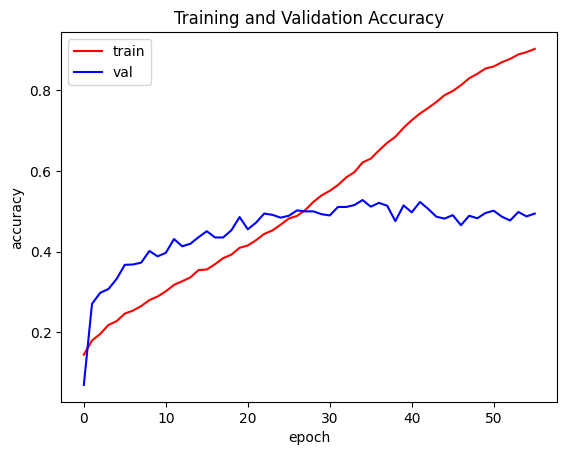

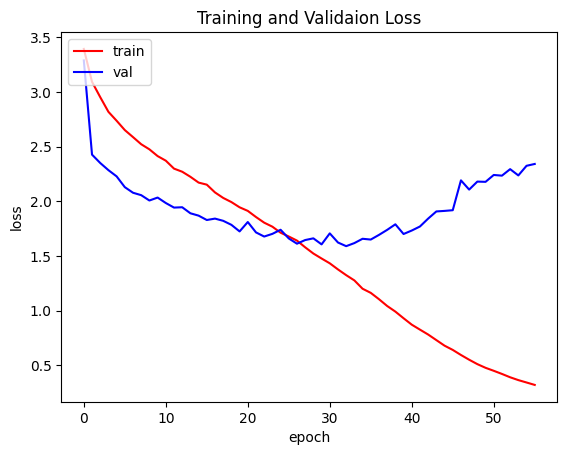

In [ ]:
acc = history_1.history['accuracy'] + history_2.history['accuracy']
val_acc = history_1.history['val_accuracy'] + history_2.history['val_accuracy']
loss = history_1.history['loss'] + history_2.history['loss']
val_loss = history_1.history['val_loss'] + history_2.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

In [ ]:
#Evaluasi data train
train_acc = history_2.history['accuracy'][-1] * 100
val_acc = max(history_2.history['val_accuracy']) * 100

print(f"Train Accuracy: {train_acc:.2f}%")
print(f"Validation Accuracy: {val_acc:.2f}%")

Train Accuracy: 90.30%
Validation Accuracy: 50.16%


In [ ]:
#Evaluasi data test
test_loss, test_accuracy = model_1.evaluate(test_generator)

print(f"Akurasi akhir pada data test: {test_accuracy * 100:.2f}%")

1282/1282 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5117 - loss: 2.1574
Akurasi akhir pada data test: 51.17%


## **2. Skeam Transfer Learning Arsitektur dengan MobilNetV2**

In [ ]:
#Inisialisasi transfer learning
base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False #Membuka bobot model pra latih

/tmp/ipykernel_9332/1651230751.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
n = train_generator.num_classes

# Susun Arsitektur Model 2
model_2 = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(n, activation='softmax')
])

# Compile Model 2 (Gunakan LR 0.0001 untuk Transfer Learning)
model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Setup Callback Khusus Model 2 (Ubah format simpan ke .keras)
class StopAtThreshold(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        # Menggunakan 'accuracy' untuk data training
        if(logs.get('accuracy') >= 0.96):
            print(f"\n[INFO] Akurasi telah mencapai {logs.get('accuracy'):.2%}, menghentikan training!")
            self.model.stop_training = True

# Inisialisasi callback custom
custom_stop_2 = StopAtThreshold()

checkpoint_model_2 = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/Computer_Vision/model_2_mobilenet.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [ ]:
import math

batch_size = 64

steps_per_epoch = math.ceil(train_generator.samples / batch_size)
val_steps = math.ceil(validation_generator.samples / batch_size)

#Fitting/training model
history_mod2 = model_2.fit(train_generator,
                           steps_per_epoch = steps_per_epoch,
                           epochs=50,
                           validation_data=validation_generator,
                           validation_steps = val_steps,
                           #class_weight= class_weights,
                           callbacks = [checkpoint_model_2, early_stop, custom_stop_2],
                           verbose=1)

Epoch 1/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.2129 - loss: 3.1609
Epoch 1: val_accuracy improved from None to 0.62168, saving model to /content/drive/MyDrive/Computer_Vision/model_2_mobilenet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Computer_Vision/model_2_mobilenet.keras
320/320 ━━━━━━━━━━━━━━━━━━━━ 83s 198ms/step - accuracy: 0.3161 - loss: 2.5900 - val_accuracy: 0.6217 - val_loss: 1.3135
Epoch 2/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4718 - loss: 1.8286
Epoch 2: val_accuracy improved from 0.62168 to 0.68097, saving model to /content/drive/MyDrive/Computer_Vision/model_2_mobilenet.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Computer_Vision/model_2_mobilenet.keras
320/320 ━━━━━━━━━━━━━━━━━━━━ 29s 90ms/step - accuracy: 0.4885 - loss: 1.7575 - val_accuracy: 0.6810 - val_loss: 1.1277
Epoch 3/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5434 - loss: 1.5454
Epoch 3: val_accuracy improved from 

#### **Fine tuning**

In [ ]:
#Memanggil model terbaik
model_2 = tf.keras.models.load_model('/content/drive/MyDrive/Computer_Vision/model_2_mobilenet.keras')

In [ ]:
#trans ferlearning kedua
base_model2 = model_2.layers[0]

base_model2.trainable = True

#buka 30 layer terakhir
for layer in base_model2.layers[:-30]:
    layer.trainable=False

In [ ]:
#compile ulang
model_2.compile(
    optimizer = tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#callbak fine tuning
checkpoint_ft = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/Computer_Vision/model_2ft_mobilenet.keras',
    monitor = 'val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [ ]:
history_mod2ft = model_2.fit(train_generator,
                             initial_epoch=19,
                             epochs=50,
                             validation_data=validation_generator,
                             callbacks = [checkpoint_ft, early_stop, custom_stop_2, reduce_lr],
                             verbose=1)

Epoch 20/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5695 - loss: 1.4262
Epoch 20: val_accuracy improved from None to 0.71841, saving model to /content/drive/MyDrive/Computer_Vision/model_2ft_mobilenet.keras

Epoch 20: finished saving model to /content/drive/MyDrive/Computer_Vision/model_2ft_mobilenet.keras
320/320 ━━━━━━━━━━━━━━━━━━━━ 66s 148ms/step - accuracy: 0.5821 - loss: 1.3776 - val_accuracy: 0.7184 - val_loss: 1.0993 - learning_rate: 1.0000e-05
Epoch 21/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6292 - loss: 1.2019
Epoch 21: val_accuracy did not improve from 0.71841
320/320 ━━━━━━━━━━━━━━━━━━━━ 28s 87ms/step - accuracy: 0.6329 - loss: 1.1770 - val_accuracy: 0.7145 - val_loss: 1.0720 - learning_rate: 1.0000e-05
Epoch 22/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6639 - loss: 1.0839
Epoch 22: val_accuracy did not improve from 0.71841
320/320 ━━━━━━━━━━━━━━━━━━━━ 28s 86ms/step - accuracy: 0.6662 - loss: 1.0645 - val_accuracy: 0.7137 

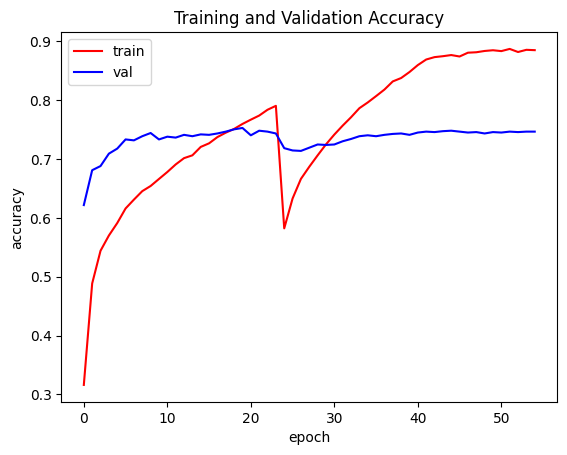

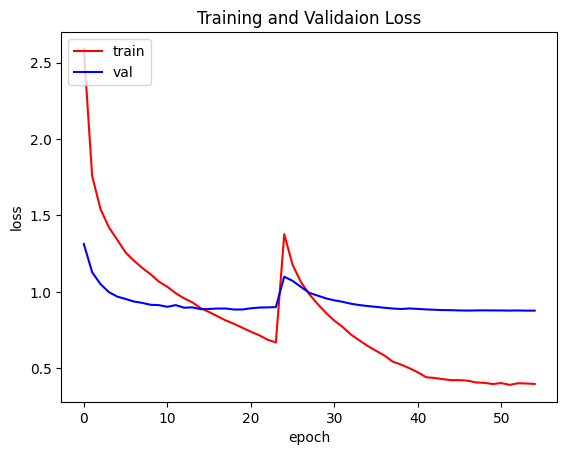

In [ ]:
acc_mod2 = history_mod2.history['accuracy'] + history_mod2ft.history['accuracy']
val_acc_mod2 = history_mod2.history['val_accuracy'] + history_mod2ft.history['val_accuracy']
loss_mod2 = history_mod2.history['loss'] + history_mod2ft.history['loss']
val_loss_mod2 = history_mod2.history['val_loss'] + history_mod2ft.history['val_loss']

epochs_mod2 = range(len(acc_mod2))

plt.plot(epochs_mod2, acc_mod2, 'r')
plt.plot(epochs_mod2, val_acc_mod2, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs_mod2, loss_mod2, 'r')
plt.plot(epochs_mod2, val_loss_mod2, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

In [ ]:
#Evaluasi data train
train_acc2 = history_mod2ft.history['accuracy'][-1] * 100
val_acc2 = max(history_mod2ft.history['val_accuracy']) * 100

print(f"Train Accuracy: {train_acc2:.2f}%")
print(f"Validation Accuracy: {val_acc2:.2f}%")

Train Accuracy: 88.49%
Validation Accuracy: 74.80%


In [ ]:
#Evaluasi data test
best_model = load_model('/content/drive/MyDrive/Computer_Vision/model_2ft_mobilenet.keras')

test_loss2, test_acc2 = best_model.evaluate(test_generator)
test_acc_percent = test_acc2 * 100

print(f"Test Accuracy: {test_acc_percent:.2f}%")

1282/1282 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.7761 - loss: 0.7928
Test Accuracy: 77.61%


## **3. Skema Transfer Learning EfficientNetB0**

In [10]:
base_model_eff = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_eff.trainable = False #membekukan bobot

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
n =train_generator.num_classes

model_efn = tf.keras.models.Sequential([
    base_model_eff,

    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(n, activation='softmax')
])

In [12]:
model_efn.compile(
    optimizer = tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

class StopAtThreshold(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') >= 0.95:
            print(f"\n[INFO] Validation Accuracy mencapai {logs.get('val_accuracy'):.2%}")
            self.model.stop_training =True

custom_stop_eff = StopAtThreshold()

checkpoint_stage1 = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Computer_Vision/efficientnet_stage1.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [13]:
history_stage1 = model_efn.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks = [checkpoint_stage1, early_stop, reduce_lr, custom_stop_eff],
    verbose=1
)

Epoch 1/50
639/639 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.4291 - loss: 2.0881
Epoch 1: val_accuracy improved from None to 0.79563, saving model to /content/drive/MyDrive/Computer_Vision/efficientnet_stage1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Computer_Vision/efficientnet_stage1.keras
639/639 ━━━━━━━━━━━━━━━━━━━━ 120s 133ms/step - accuracy: 0.5360 - loss: 1.6427 - val_accuracy: 0.7956 - val_loss: 0.6863 - learning_rate: 1.0000e-04
Epoch 2/50
638/639 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6581 - loss: 1.1443
Epoch 2: val_accuracy improved from 0.79563 to 0.81123, saving model to /content/drive/MyDrive/Computer_Vision/efficientnet_stage1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Computer_Vision/efficientnet_stage1.keras
639/639 ━━━━━━━━━━━━━━━━━━━━ 39s 60ms/step - accuracy: 0.6699 - loss: 1.1163 - val_accuracy: 0.8112 - val_loss: 0.6122 - learning_rate: 1.0000e-04
Epoch 3/50
639/639 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accu

#### **Fine Tuning**

In [14]:
model_efn = tf.keras.models.load_model('/content/drive/MyDrive/Computer_Vision/efficientnet_stage1.keras')

In [15]:
base_model_eff = model_efn.layers[0]

base_model_eff.trainabele =True

#Freeze sebagian besar layer
for layer in base_model_eff.layers[:-30]:
    layer.trainable = False

In [16]:
model_efn.compile(
    optimizer= tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
checkpoint_stage2 = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Computer_Vision/efficientnet_finetune.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [18]:
history_stage2 = model_efn.fit(
    train_generator,
    initial_epoch=11,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[
        checkpoint_stage2,
        early_stop,
        reduce_lr,
        custom_stop_eff
    ],
    verbose=1
)

Epoch 12/50
638/639 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9026 - loss: 0.3224
Epoch 12: val_accuracy improved from None to 0.83931, saving model to /content/drive/MyDrive/Computer_Vision/efficientnet_finetune.keras

Epoch 12: finished saving model to /content/drive/MyDrive/Computer_Vision/efficientnet_finetune.keras
639/639 ━━━━━━━━━━━━━━━━━━━━ 94s 107ms/step - accuracy: 0.8995 - loss: 0.3264 - val_accuracy: 0.8393 - val_loss: 0.5383 - learning_rate: 1.0000e-05
Epoch 13/50
639/639 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8981 - loss: 0.3217
Epoch 13: val_accuracy improved from 0.83931 to 0.84399, saving model to /content/drive/MyDrive/Computer_Vision/efficientnet_finetune.keras

Epoch 13: finished saving model to /content/drive/MyDrive/Computer_Vision/efficientnet_finetune.keras

Epoch 13: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
639/639 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.8993 - loss: 0.3223 - val_accuracy: 0.8440 - val_loss: 0.

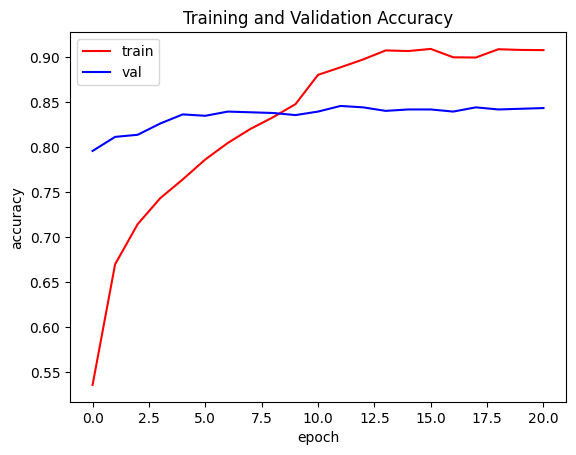

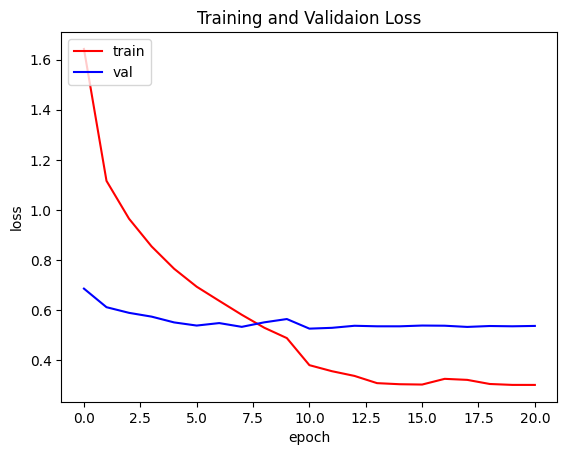

In [19]:
acc_efn = history_stage1.history['accuracy'] + history_stage2.history['accuracy']
val_acc_efn = history_stage1.history['val_accuracy']+ history_stage2.history['val_accuracy']
loss_efn = history_stage1.history['loss'] + history_stage2.history['loss']
val_loss_efn = history_stage1.history['val_loss'] + history_stage2.history['val_loss']

epochs_efn = range(len(acc_efn))

plt.plot(epochs_efn, acc_efn, 'r')
plt.plot(epochs_efn, val_acc_efn, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs_efn, loss_efn, 'r')
plt.plot(epochs_efn, val_loss_efn, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

In [20]:
#Evaluasi data train
train_acceff = history_stage2.history['accuracy'][-1] * 100
val_acceff = max(history_stage2.history['val_accuracy']) * 100

print(f"Train Accuracy: {train_acceff:.2f}%")
print(f"Validation Accuracy: {val_acceff:.2f}%")

Train Accuracy: 90.75%
Validation Accuracy: 84.40%


In [21]:
#Evaluasi data test
best_model_ft = load_model('/content/drive/MyDrive/Computer_Vision/efficientnet_finetune.keras')

test_losseff, test_acceff = best_model_ft.evaluate(test_generator)
test_acc_percent = test_acceff * 100

print(f"Test Accuracy: {test_acc_percent:.2f}%")

1282/1282 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - accuracy: 0.8619 - loss: 0.4683
Test Accuracy: 86.19%


## **Menyimpan Model**

In [22]:
#1.SaveModel

n =train_generator.num_classes

model_efn = tf.keras.models.Sequential([
    base_model_eff,

    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(n, activation='softmax')
])

#Ekspor model menjadi SaveModel
model_efn.export("/content/drive/MyDrive/Computer_Vision/save_model")

Saved artifact at '/content/drive/MyDrive/Computer_Vision/save_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_1327')
Output Type:
  TensorSpec(shape=(None, 23), dtype=tf.float32, name=None)
Captures:
  137794499604176: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137794499605712: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137797523714320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137797251574544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137797251573392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137797523711248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137797251572432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137797251576272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137797251574928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137797251573776: TensorSpec

In [24]:
#2. Konversi SaveModel ke TF-Lite
from tensorflow.keras.models import load_model

save_path = '/content/drive/MyDrive/Computer_Vision/save_model'

# Konversi model Keras ke TF-Lite
converter = tf.lite.TFLiteConverter.from_saved_model(save_path)

tflite_model = converter.convert()

with open('/content/drive/MyDrive/Computer_Vision/tflite/model_eff.tflite', 'wb') as f:
    f.write(tflite_model)

In [25]:
print(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())
output_path = '/content/drive/MyDrive/Computer_Vision/tflite/labels.txt'

with open(output_path, 'w') as f:
    for name in class_names:
        f.write(f"{name}\n")

print("File labels.txt berhasil dibuat otomatis langsung dari train_generator!")

{'Clams': 0, 'Corals': 1, 'Crabs': 2, 'Dolphin': 3, 'Eel': 4, 'Fish': 5, 'Jelly Fish': 6, 'Lobster': 7, 'Nudibranchs': 8, 'Octopus': 9, 'Otter': 10, 'Penguin': 11, 'Puffers': 12, 'Sea Rays': 13, 'Sea Urchins': 14, 'Seahorse': 15, 'Seal': 16, 'Sharks': 17, 'Shrimp': 18, 'Squid': 19, 'Starfish': 20, 'Turtle_Tortoise': 21, 'Whale': 22}
File labels.txt berhasil dibuat otomatis langsung dari train_generator!


In [27]:
!pip install tensorflowjs

INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting un

In [1]:
#3. Konversi dari SaveModel ke TF-js
import tensorflow as tf
import tensorflowjs as tfjs

!tensorflowjs_converter --input_format=tf_saved_model /content/drive/MyDrive/Computer_Vision/save_model /content/drive/MyDrive/Computer_Vision/tfjs_model


print("Konversi ke TensorFlow.js berhasil!")

2026-05-20 01:57:28.299093: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779242248.334315   10817 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779242248.346625   10817 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779242248.374017   10817 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779242248.374052   10817 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779242248.374063   10817 computation_placer.cc:177] computation placer alr

In [2]:
!pip freeze > requirements.txt

In [3]:
# Konten teks menggunakan sintaks Markdown
isi_readme = """Computer Vision for Sea Animal"

Proyek ini menggunakan data set binatang laut yang banyak diambil didalam air.
Augmentasi proyek ini dilakukan secara manual (off-line augmentation) yang disimpan ke dalam drive,
dimana data asli di lakukan proses augmentasi dan disimpan ke dalam folder sendiri.
Kemudian dataset asli dibagi menjadi train, validation dan test. Data gambar augmentasi digabung ke dalam
folder train

## 🛠️ Cara Instalasi
```bsh
pip install -r requirements.txt
```

## Arsitektur
Project ini menggunakan tiga skema arsitektur
1. CNN menggunakan Conv2D dan MaxPooling dengan akurasi train 90.30% dan akurasi test 51.17%
2. Transfer Learning MobileNetV2 dan fine tuning dengan akurasi train 88.49% dan akurasi test 77.61%
3. Transfer Learning EfficientNetB0 dan fine tuning dengan akurasi train 90.75% dan akurasi test 86.19%

"""

# Membuat dan menulis ke file README.md
with open("README.md", "w", encoding="utf-8") as file:
    file.write(isi_readme)

print("File README.md berhasil dibuat!")

File README.md berhasil dibuat!


## **Testing**

In [4]:
save_path = '/content/drive/MyDrive/Computer_Vision/efficientnet_finetune.keras'

model= tf.keras.models.load_model(save_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


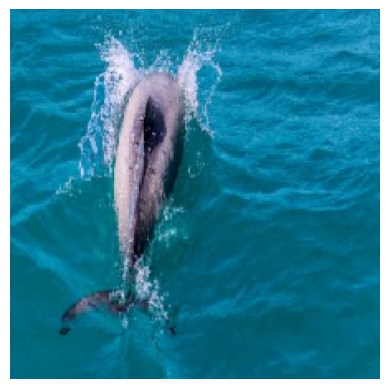

In [17]:
from tensorflow.keras.preprocessing import image

#Mengambil gambar dari google drive
from google.colab import drive
drive.mount('/content/drive')

img_path = '/content/drive/MyDrive/Computer_Vision/test/Dolphin/Dolphin_174.jpg'

# Load gambar
img = image.load_img(img_path, target_size=(224, 224))

# Tampilkan gambar
plt.imshow(img)
plt.axis('off')
plt.show()

In [18]:
#Preprocessing dan inference
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = eff_preprocessing(img_array)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction) * 100

print(f"Predicted Class : {predicted_class}")
print(f"Confidence      : {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Predicted Class : 3
Confidence      : 99.93%


In [24]:
print(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())
print(class_names)

{'Clams': 0, 'Corals': 1, 'Crabs': 2, 'Dolphin': 3, 'Eel': 4, 'Fish': 5, 'Jelly Fish': 6, 'Lobster': 7, 'Nudibranchs': 8, 'Octopus': 9, 'Otter': 10, 'Penguin': 11, 'Puffers': 12, 'Sea Rays': 13, 'Sea Urchins': 14, 'Seahorse': 15, 'Seal': 16, 'Sharks': 17, 'Shrimp': 18, 'Squid': 19, 'Starfish': 20, 'Turtle_Tortoise': 21, 'Whale': 22}
['Clams', 'Corals', 'Crabs', 'Dolphin', 'Eel', 'Fish', 'Jelly Fish', 'Lobster', 'Nudibranchs', 'Octopus', 'Otter', 'Penguin', 'Puffers', 'Sea Rays', 'Sea Urchins', 'Seahorse', 'Seal', 'Sharks', 'Shrimp', 'Squid', 'Starfish', 'Turtle_Tortoise', 'Whale']


In [25]:
print(f"Ini gambar {class_names[predicted_class]}")

Ini gambar Dolphin
